# 04 · Entrenamiento de Modelos
**Proyecto:** Predicción de abandono de clientes – Telco Customer Churn

---
## Objetivo de este notebook
Entrenar los dos modelos obligatorios del proyecto — Regresión Logística y Árbol de Decisión —
y ajustar sus hiperparámetros para encontrar la mejor configuración de cada uno.

**Imports**

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score


**Carga de datasets**

In [44]:

# Regresión Logística usa datos escalados
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_val_scaled   = pd.read_csv('../data/processed/X_val_scaled.csv')

# Árbol de Decisión usa datos sin escalar
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()


In [45]:
print(f'Train: {X_train.shape[0]} muestras')
print(f'Val:   {X_val.shape[0]} muestras')

Train: 4225 muestras
Val:   1409 muestras


## Regresión Logística

La Regresión Logística es un modelo lineal que estima la probabilidad de pertenencia a una clase.
Es interpretable directamente a través de sus coeficientes: un coeficiente positivo aumenta
la probabilidad de churn, uno negativo la reduce.

Este modelo permite comparar un enfoque lineal contra uno basado en reglas,
y sus coeficientes responden directamente la pregunta guía del proyecto.

**Modelo base**

In [46]:
lr_base = LogisticRegression(random_state=42, max_iter=1000)
lr_base.fit(X_train_scaled, y_train)

y_pred_lr_base = lr_base.predict(X_val_scaled)
y_prob_lr_base = lr_base.predict_proba(X_val_scaled)[:, 1]

print('=== Regresión Logística — Modelo Base ===')
print(f'F1-score: {f1_score(y_val, y_pred_lr_base):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_val, y_prob_lr_base):.4f}')

=== Regresión Logística — Modelo Base ===
F1-score: 0.5879
ROC-AUC:  0.8361


### 1.2 Ajuste de hiperparámetros — parámetro C

`C` controla la regularización. En este caso, los modelos pequeños aplican más regularización, mientras que los modelos más flexibles la reducen. Se busca el balance que mejor generaliza.

In [47]:
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print(f'Mejor C:        {grid_lr.best_params_["C"]}')
print(f'ROC-AUC (CV):   {grid_lr.best_score_:.4f}')

Mejor C:        1
ROC-AUC (CV):   0.8486


Un valor de `C = 1` significa que el modelo está bien calibrado y no necesita regularización adicional.

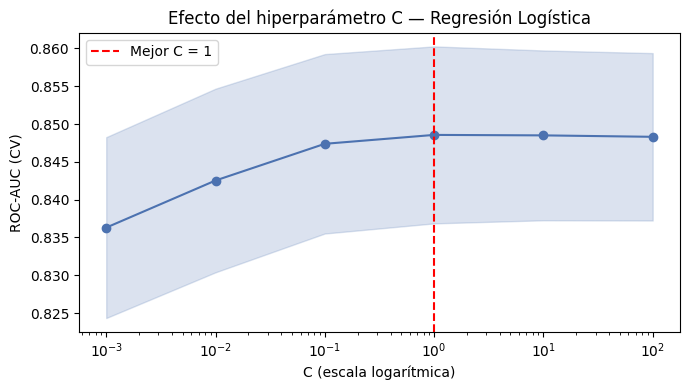

In [48]:
# Visualizar efecto de C
results_lr = pd.DataFrame(grid_lr.cv_results_)

plt.figure(figsize=(7, 4))
plt.semilogx(param_grid_lr['C'], results_lr['mean_test_score'], 'o-', color='#4C72B0')
plt.fill_between(
    param_grid_lr['C'],
    results_lr['mean_test_score'] - results_lr['std_test_score'],
    results_lr['mean_test_score'] + results_lr['std_test_score'],
    alpha=0.2, color='#4C72B0'
)
plt.axvline(grid_lr.best_params_['C'], color='red', linestyle='--',
            label=f'Mejor C = {grid_lr.best_params_["C"]}')
plt.xlabel('C (escala logarítmica)')
plt.ylabel('ROC-AUC (CV)')
plt.title('Efecto del hiperparámetro C — Regresión Logística')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
lr_best = grid_lr.best_estimator_
y_pred_lr = lr_best.predict(X_val_scaled)
y_prob_lr = lr_best.predict_proba(X_val_scaled)[:, 1]

print('=== Regresión Logística con mejor estimación ===')
print(f'C:        {grid_lr.best_params_["C"]}')
print(f'F1-score: {f1_score(y_val, y_pred_lr):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_val, y_prob_lr):.4f}')

=== Regresión Logística con mejor estimación ===
C:        1
F1-score: 0.5879
ROC-AUC:  0.8361


* El área bajo la curva demuestra que el modelo ordena correctamente clientes por riesgo de abandono el 83.6% de veces.
* El F1-score muestra un moderado desequilibrio entre precisión y recall, lo cual es normal considerando que el dataset está desbalanceado.

Por ahora el modelo sirve para el ranking de clientes por riesgo de abandonar.



**Probabilidades individuales**

La Regresión Logística no solo predice una clase, sino que también entrega la probabilidad de cada predicción. Esto permite priorizar intervenciones según el nivel de riesgo.

In [50]:
probs = lr_best.predict_proba(X_val_scaled)

print(f"{'Predicción':<14} {'P(No Churn)':<14} {'P(Churn)':<12} {'Real'}")
print('-' * 55)
for i in range(10):
    pred = 'Churn'    if y_pred_lr[i] == 1 else 'No Churn'
    real = 'Churn'    if list(y_val)[i] == 1 else 'No Churn'
    print(f"{pred:<14} {probs[i][0]:<14.3f} {probs[i][1]:<12.3f} {real}")

Predicción     P(No Churn)    P(Churn)     Real
-------------------------------------------------------
Churn          0.354          0.646        No Churn
Churn          0.267          0.733        No Churn
Churn          0.344          0.656        No Churn
Churn          0.394          0.606        No Churn
No Churn       0.979          0.021        No Churn
No Churn       0.806          0.194        No Churn
No Churn       0.989          0.011        No Churn
No Churn       0.978          0.022        No Churn
Churn          0.262          0.738        Churn
No Churn       0.998          0.002        No Churn


Se decide reajustar el umbral para mejorar el problema de falsos positivos constantes.

In [51]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print(f"{'Umbral':<10} {'Precision':<12} {'Recall':<10} {'F1-score':<10}")
print('-' * 48)
for threshold in thresholds:
    y_pred_threshold = (y_prob_lr >= threshold).astype(int)
    precision = precision_score(y_val, y_pred_threshold)
    recall = recall_score(y_val, y_pred_threshold)
    f1 = f1_score(y_val, y_pred_threshold)
    print(f"{threshold:<10.1f} {precision:<12.4f} {recall:<10.4f} {f1:<10.4f}")

Umbral     Precision    Recall     F1-score  
------------------------------------------------
0.2        0.4652       0.8396     0.5987    
0.3        0.5383       0.7513     0.6272    
0.4        0.5965       0.6444     0.6195    
0.5        0.6568       0.5321     0.5879    
0.6        0.7121       0.3770     0.4930    
0.7        0.7558       0.1738     0.2826    
0.8        0.7778       0.0187     0.0366    


Dado el objetivo del proyecto, el umbral 0.3 ofrece el mejor equilibrio entre precisión y recall.

**Probabilidades individuales con umbral = 0.3**

In [52]:
threshold = 0.3
y_pred_threshold = (y_prob_lr >= threshold).astype(int)

probs = lr_best.predict_proba(X_val_scaled)

print(f"{'Predicción':<14} {'P(No Churn)':<14} {'P(Churn)':<12} {'Real'}")
print('-' * 55)
for i in range(10):
    pred = 'Churn' if y_pred_threshold[i] == 1 else 'No Churn'
    real = 'Churn' if y_val.iloc[i] == 1 else 'No Churn'
    print(f"{pred:<14} {probs[i][0]:<14.3f} {probs[i][1]:<12.3f} {real}")

Predicción     P(No Churn)    P(Churn)     Real
-------------------------------------------------------
Churn          0.354          0.646        No Churn
Churn          0.267          0.733        No Churn
Churn          0.344          0.656        No Churn
Churn          0.394          0.606        No Churn
No Churn       0.979          0.021        No Churn
No Churn       0.806          0.194        No Churn
No Churn       0.989          0.011        No Churn
No Churn       0.978          0.022        No Churn
Churn          0.262          0.738        Churn
No Churn       0.998          0.002        No Churn


**Variables más influyentes en el abandono de clientes**

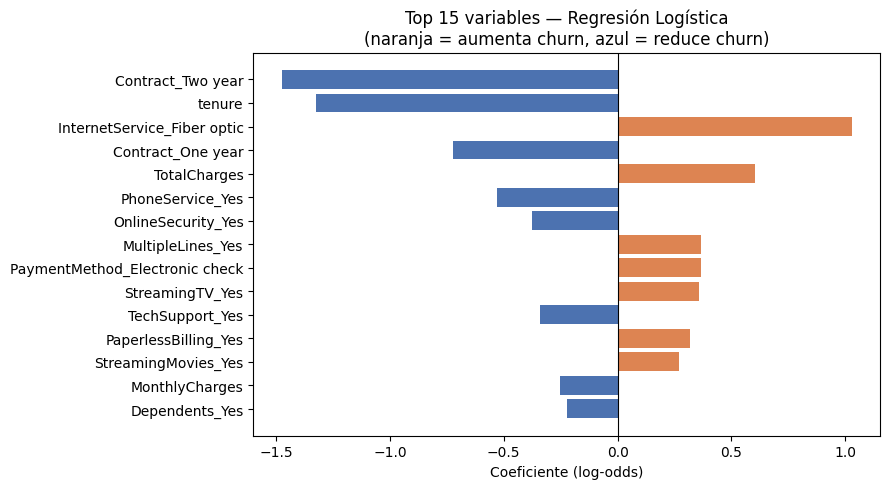

In [53]:
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coef': lr_best.coef_[0]
}).sort_values('coef', key=abs, ascending=False).head(15)

colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['coef']]

plt.figure(figsize=(9, 5))
plt.barh(coef_df['feature'], coef_df['coef'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (log-odds)')
plt.title('Top 15 variables — Regresión Logística\n(naranja = aumenta churn, azul = reduce churn)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Árbol de Decisión

El Árbol de Decisión divide los datos mediante reglas de tipo *si/entonces* sobre los valores
de las variables. Es altamente interpretable: se puede visualizar el árbol completo y leer
exactamente qué condiciones llevan a predecir churn.

Este modelo complementa a la Regresión Logística con un enfoque no lineal
basado en reglas, más fácil de comunicar a equipos no técnicos.

**Modelo base**

In [54]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

f1_train = f1_score(y_train, dt_base.predict(X_train))
f1_val   = f1_score(y_val,   dt_base.predict(X_val))

print('=== Árbol de Decisión sin restricciones ===')
print(f'Profundidad: {dt_base.get_depth()}')
print(f'F1 train:    {f1_train:.4f}')
print(f'F1 val:      {f1_val:.4f}')

=== Árbol de Decisión sin restricciones ===
Profundidad: 30
F1 train:    0.9969
F1 val:      0.4781


El árbol aprendió reglas muy específicas, dejándolo demasiado complejo y capturó patrones muy particulares del train, simbolizando problemas de overfitting; como también generaliza mal.

**Ajuste de hiperparámetros**

- `max_depth`: limita la profundidad del árbol para evitar overfitting
- `criterion`: criterio de división de nodos (`gini` o `entropy`)

In [55]:
param_grid_dt = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print(f'Mejores parámetros: {grid_dt.best_params_}')
print(f'ROC-AUC (CV):       {grid_dt.best_score_:.4f}')

Mejores parámetros: {'criterion': 'entropy', 'max_depth': 6}
ROC-AUC (CV):       0.8232


El modelo queda más equilibrado al reducir la profundidad del árbol, como también baja el overfitting.

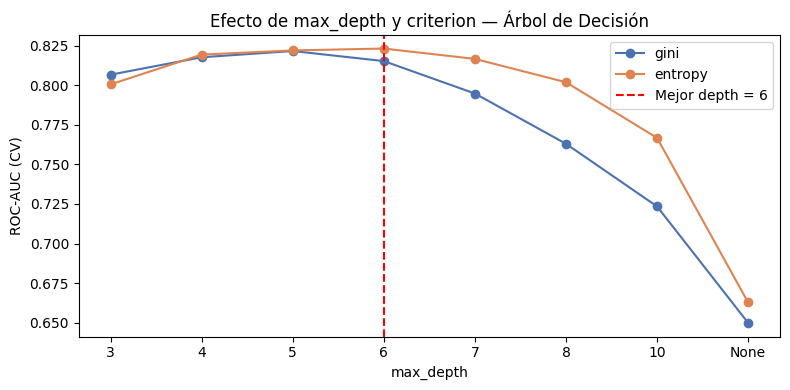

In [56]:
results_dt = pd.DataFrame(grid_dt.cv_results_)
depth_labels = [str(d) if d is not None else 'None' for d in param_grid_dt['max_depth']]

plt.figure(figsize=(8, 4))
for criterion, color in [('gini', '#4C72B0'), ('entropy', '#DD8452')]:
    mask = results_dt['param_criterion'] == criterion
    scores = results_dt[mask]['mean_test_score'].values
    plt.plot(depth_labels, scores, 'o-', label=criterion, color=color)

best_depth = grid_dt.best_params_['max_depth']
best_label = str(best_depth) if best_depth is not None else 'None'
plt.axvline(best_label, color='red', linestyle='--', label=f'Mejor depth = {best_label}')
plt.xlabel('max_depth')
plt.ylabel('ROC-AUC (CV)')
plt.title('Efecto de max_depth y criterion — Árbol de Decisión')
plt.legend()
plt.tight_layout()
plt.show()

La curva llega al balance óptimo al cruzar una profundidad de 6 niveles con el criterio entropy (divisiones minimizando incertidumbre). Los árboles profundos causan overfitting y los más superficiales subestiman los patrones del modelo.

In [57]:
dt_best = grid_dt.best_estimator_
y_pred_dt = dt_best.predict(X_val)
y_prob_dt = dt_best.predict_proba(X_val)[:, 1]

print('=== Árbol de Decisión con mejor estimación ===')
print(f'max_depth: {grid_dt.best_params_["max_depth"]}')
print(f'criterion: {grid_dt.best_params_["criterion"]}')
print(f'F1-score:  {f1_score(y_val, y_pred_dt):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_val, y_prob_dt):.4f}')

=== Árbol de Decisión con mejor estimación ===
max_depth: 6
criterion: entropy
F1-score:  0.5041
ROC-AUC:   0.8111


**Visualización del árbol**

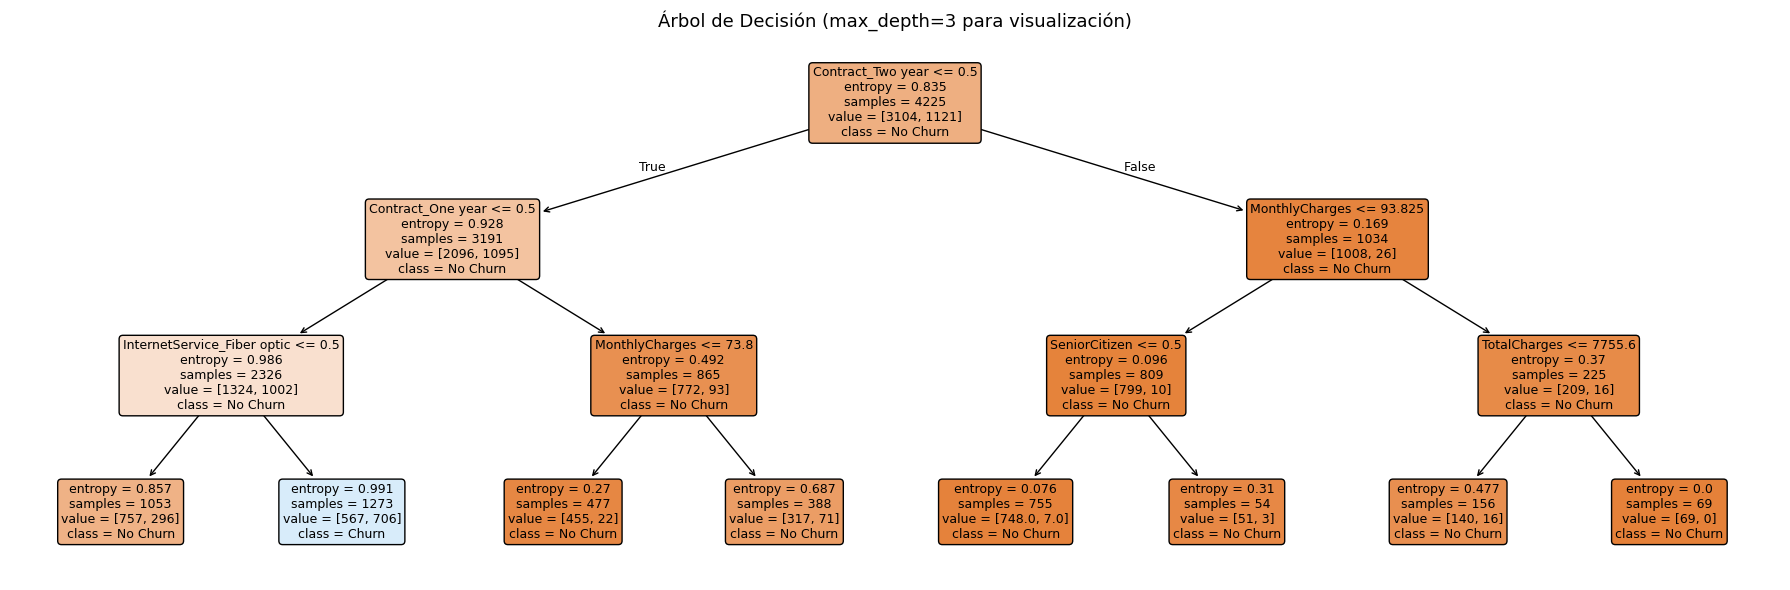

In [58]:
from sklearn.tree import plot_tree

# max_depth=3 para una mejor legibilidad
dt_viz = DecisionTreeClassifier(
    max_depth=3,
    criterion=grid_dt.best_params_['criterion'],
    random_state=42
)
dt_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    dt_viz,
    feature_names=X_train.columns.tolist(),
    class_names=['No Churn', 'Churn'],
    filled=True, rounded=True, fontsize=9, ax=ax
)
plt.title('Árbol de Decisión (max_depth=3 para visualización)', fontsize=13)
plt.tight_layout()
plt.show()

**Variables más importantes**

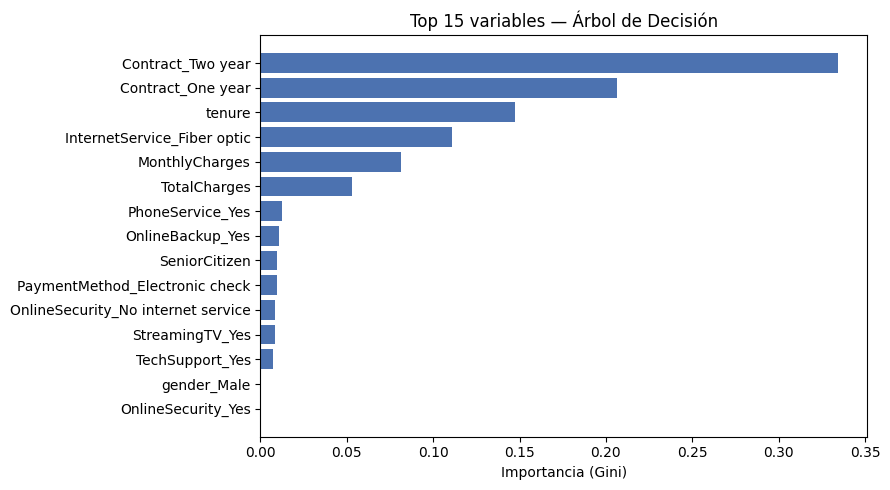

In [59]:
fi_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_best.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 5))
plt.barh(fi_df['feature'], fi_df['importance'], color='#4C72B0')
plt.xlabel('Importancia (Gini)')
plt.title('Top 15 variables — Árbol de Decisión')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Guardar modelos entrenados**

In [60]:
joblib.dump(lr_best, '../models/logistic_regression.joblib')
joblib.dump(dt_best, '../models/decision_tree.joblib')

['../models/decision_tree.joblib']